**Stock marketing prediction**

Epoch 1/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4854 - loss: 1.1758 - val_accuracy: 0.2716 - val_loss: 0.7509 - learning_rate: 0.0010
Epoch 2/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4849 - loss: 0.7914 - val_accuracy: 0.2684 - val_loss: 0.7218 - learning_rate: 0.0010
Epoch 3/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5191 - loss: 0.7237 - val_accuracy: 0.2875 - val_loss: 0.7306 - learning_rate: 0.0010
Epoch 4/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4886 - loss: 0.7069 - val_accuracy: 0.6837 - val_loss: 0.6509 - learning_rate: 0.0010
Epoch 5/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5056 - loss: 0.6950 - val_accuracy: 0.2971 - val_loss: 0.7469 - learning_rate: 0.0010
Epoch 6/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5811 - loss: 0.7021 - val_accuracy: 0.5879 - val_loss: 0.6902 - learning_rate: 0.0010
Epoch 7/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5784 - loss: 0.6751 - val_acc

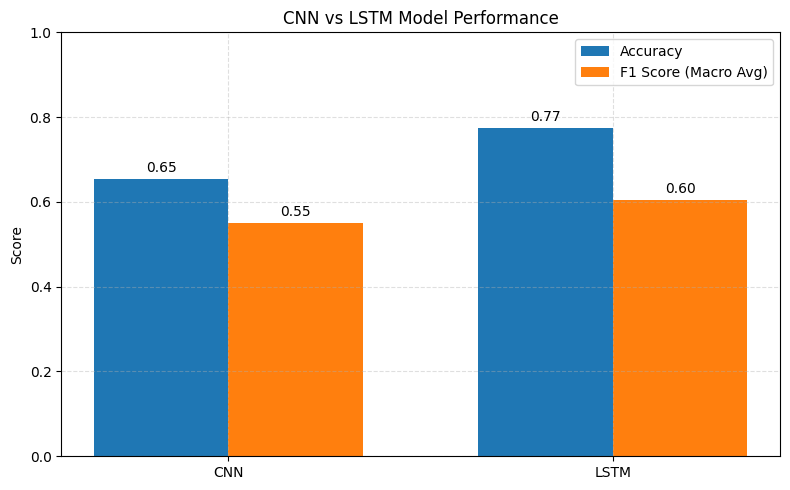

In [3]:
# --- LIBRARIES ---
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve, f1_score
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Flatten, Dense, Dropout,
    BatchNormalization, LSTM, Add
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# --- LOAD & CLEAN DATA ---
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Processed_S&P.csv')
df.ffill(inplace=True)
df.bfill(inplace=True)
df.dropna(inplace=True)

# --- CREATE TARGET ---
df['Return'] = df['Close'].pct_change().shift(-1)
df['Target'] = (df['Return'] > 0.005).astype(int)
df.dropna(inplace=True)

# --- FEATURES ---
X = df.drop(columns=['Date', 'Name', 'Target', 'Return'], errors='ignore')
y = df['Target']

# --- SCALE ---
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# --- CREATE SEQUENCES ---
window = 30
X_seq, y_seq = [], []
for i in range(len(X_scaled) - window):
    X_seq.append(X_scaled[i:i + window])
    y_seq.append(y.iloc[i + window])
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# --- SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

# --- CLASS WEIGHTS ---
class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# --- CALLBACKS ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, verbose=1)

# === 📊 IMPROVED CNN MODEL ===
def build_improved_cnn(input_shape):
    input_layer = Input(shape=input_shape)

    x = Conv1D(64, kernel_size=3, activation='relu', padding='causal')(input_layer)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    x2 = Conv1D(64, kernel_size=3, activation='relu', padding='causal')(x)
    x2 = BatchNormalization()(x2)

    res = Add()([x, x2])  # Residual connection

    pool = GlobalMaxPooling1D()(res)
    dense = Dense(64, activation='relu')(pool)
    drop = Dropout(0.3)(dense)
    output = Dense(1, activation='sigmoid')(drop)

    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_improved_cnn(X_train.shape[1:])

cnn_model.fit(X_train, y_train, validation_split=0.2, epochs=60, batch_size=32,
              class_weight=class_weights_dict, callbacks=[early_stop, reduce_lr], verbose=1)

# --- CNN EVAL ---
y_prob_cnn = cnn_model.predict(X_test).flatten()
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_cnn)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_thresh_cnn = thresholds[np.argmax(f1_scores)]
y_pred_cnn = (y_prob_cnn > best_thresh_cnn).astype(int)

cnn_acc = accuracy_score(y_test, y_pred_cnn)
cnn_f1 = f1_score(y_test, y_pred_cnn)

print(f"\n📊 CNN Accuracy: {cnn_acc * 100:.2f}%")
print("📋 CNN Classification Report:\n", classification_report(y_test, y_pred_cnn))

# === 🧠 LSTM MODEL ===
lstm_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    BatchNormalization(),
    LSTM(32),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- TRAIN LSTM ---
lstm_model.fit(X_train, y_train, validation_split=0.2, epochs=60, batch_size=32,
               class_weight=class_weights_dict, callbacks=[early_stop, reduce_lr], verbose=1)

# --- LSTM EVALUATION ---
y_prob_lstm = lstm_model.predict(X_test).flatten()
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lstm)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_thresh_lstm = thresholds[np.argmax(f1_scores)]
y_pred_lstm = (y_prob_lstm > best_thresh_lstm).astype(int)

lstm_acc = accuracy_score(y_test, y_pred_lstm)
lstm_f1 = f1_score(y_test, y_pred_lstm)

print(f"\n🧠 LSTM Accuracy: {lstm_acc * 100:.2f}%")
print("📋 LSTM Classification Report:\n", classification_report(y_test, y_pred_lstm))

# === 📊 COMPARISON PLOT ===
cnn_acc = accuracy_score(y_test, y_pred_cnn)
lstm_acc = accuracy_score(y_test, y_pred_lstm)

# Generate classification reports as dict to extract macro avg F1
cnn_report = classification_report(y_test, y_pred_cnn, output_dict=True)
lstm_report = classification_report(y_test, y_pred_lstm, output_dict=True)

cnn_f1_macro = cnn_report['macro avg']['f1-score']
lstm_f1_macro = lstm_report['macro avg']['f1-score']

labels = ['CNN', 'LSTM']
acc = [cnn_acc, lstm_acc]
f1_macro = [cnn_f1_macro, lstm_f1_macro]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, acc, width, label='Accuracy')
bars2 = ax.bar(x + width/2, f1_macro, width, label='F1 Score (Macro Avg)')

ax.set_ylabel('Score')
ax.set_title('CNN vs LSTM Model Performance')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.legend()

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()